# SQLite Database Data Analysis

In this notebook, we connect to the `sales.db` database, retrieve a larger dataset, and perform advanced visualizations.

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Connect to database
db_path = '../data/sales.db'
conn = sqlite3.connect(db_path)

# 2. Load data into DataFrame
query = "SELECT * FROM sales"
df = pd.read_sql(query, conn, parse_dates=['date'])

conn.close()

print(f"Loaded {len(df)} records.")
df.head()

Loaded 2193 records.


,id,date,category,amount
0,4387,2024-01-01,Electronics,185
1,4388,2024-01-01,Clothing,172
2,4389,2024-01-01,Home & Garden,15
3,4390,2024-01-02,Electronics,227
4,4391,2024-01-02,Clothing,165


### 1. Sales Over Time (General Trend)

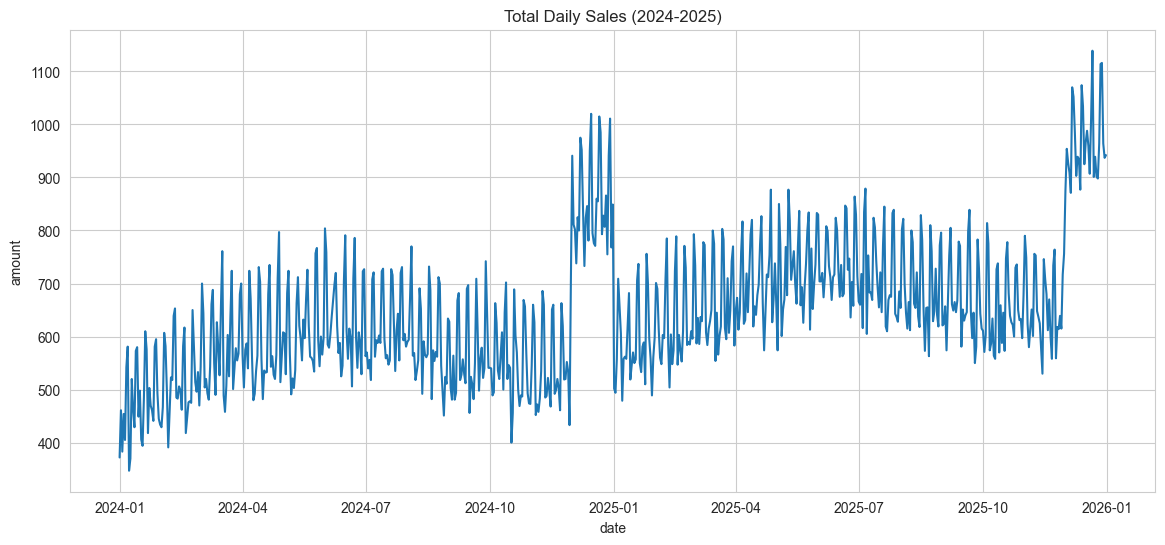

In [12]:
# Daily aggregation
daily_sales = df.groupby('date')['amount'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='date', y='amount')
plt.title('Total Daily Sales (2024-2025)')
plt.show()

### 2. Category Comparison
Let's check how individual departments are performing.

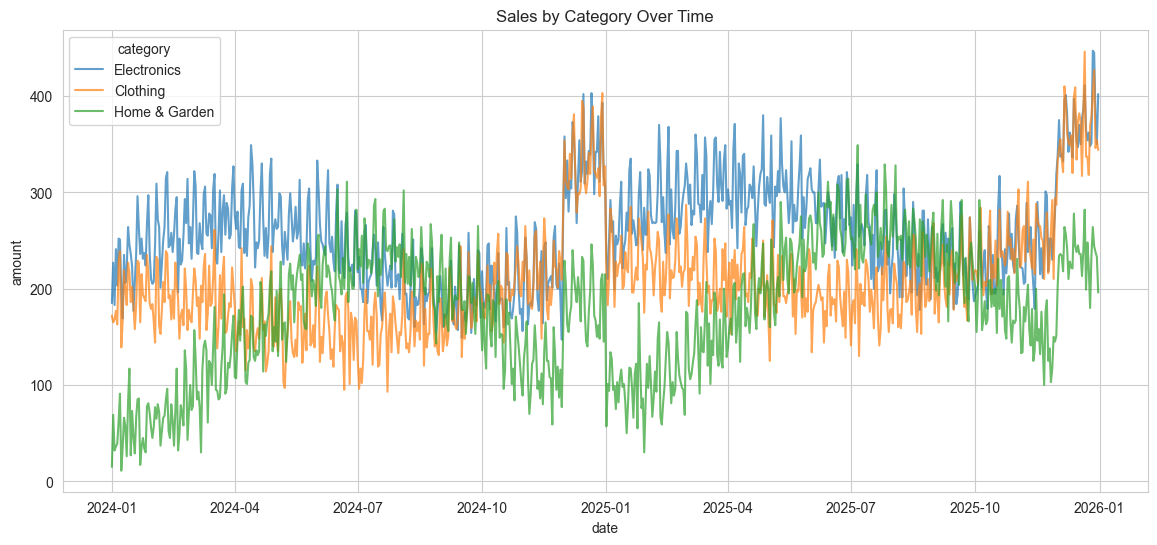

In [13]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='date', y='amount', hue='category', alpha=0.7)
plt.title('Sales by Category Over Time')
plt.show()

### 3. Monthly Analysis (Boxplot)
Is seasonality visible? A boxplot will show the sales distribution for each month.

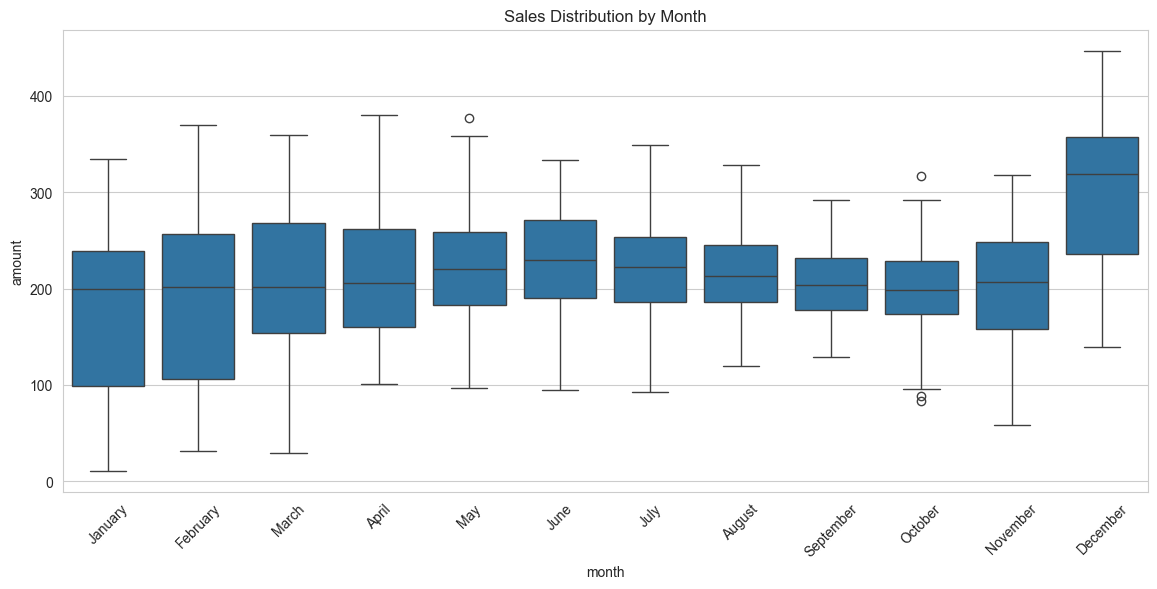

In [14]:
df['month'] = df['date'].dt.month_name()
df['month_num'] = df['date'].dt.month
df = df.sort_values('month_num')

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='month', y='amount')
plt.title('Sales Distribution by Month')
plt.xticks(rotation=45)
plt.show()

### 4. Day of the Week
Do we sell more on weekends?

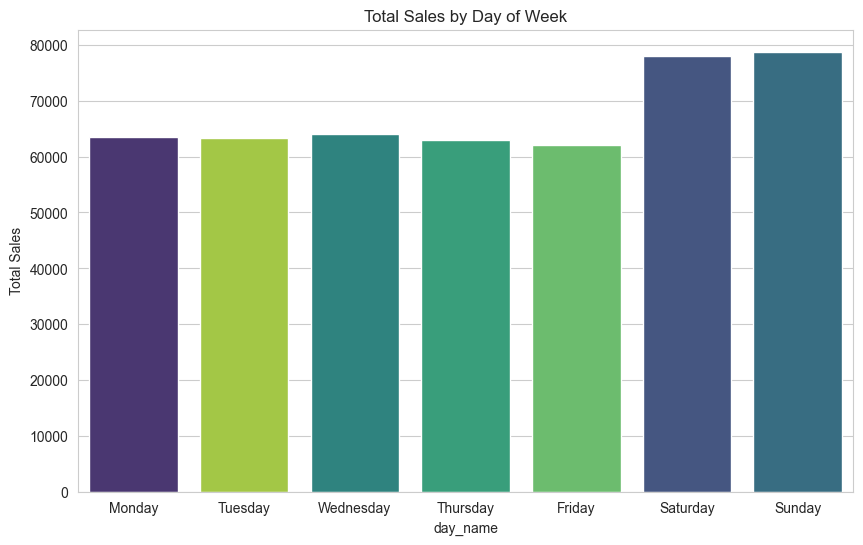

In [15]:
df['day_name'] = df['date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='day_name', y='amount', order=days_order, estimator=sum, errorbar=None, palette='viridis', hue='day_name', legend=False)
plt.title('Total Sales by Day of Week')
plt.ylabel('Total Sales')
plt.show()